본 분석은 Q1-Cluster 1(차량 의존·저인프라 시장)을 대상으로,

차량 유입 OD 원본 데이터를 활용하여

① 차량 이용자의 이동 거리

② 체류 시간

③ 방문 목적(귀가/소비)

특성을 파악하고,

소규모 환승·주차 거점 도입 필요성을 검증하는 것을 목적으로 한다.


## 데이터 로드

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)

In [2]:
df_embed_q1 = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_embed_q1.csv", encoding = 'utf-8-sig')
df_embed_q2 = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_embed_q2.csv", encoding = 'utf-8-sig')

In [71]:
import pandas as pd
import numpy as np

# 1) load
q1 = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_embed_q1.csv", encoding = 'utf-8-sig')
q2 = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\df_embed_q2.csv", encoding = 'utf-8-sig')
oof = pd.read_csv(r"C:\Users\legen\Desktop\Lab Project\BC\data\market_od_all_oof.csv", encoding = 'utf-8-sig')

# 2) 공통 키: 행정기관코드 (문자형으로 통일)
for df in (q1, q2, oof):
    if "행정기관코드" in df.columns:
        df["행정기관코드"] = df["행정기관코드"].astype(str).str.strip()

# 3) (중요) 혹시 행정기관코드가 없고 index로만 매칭해야 하는 경우 대비
# - q1/q2에 'idx' 같은 원본 인덱스가 있는지 확인하고,
# - oof에도 같은 키가 있으면 그걸로 merge 하도록 분기
print("q1 cols:", q1.columns.tolist())
print("q2 cols:", q2.columns.tolist())
print("oof cols:", oof.columns.tolist())


q1 cols: ['행정기관코드', '시장명', '시도', '시군구', 'STRUCT_PC1', 'STRUCT_PC2', 'STRUCT_PC3', 'ACCESS_PC1', 'ACCESS_PC2', 'ACCESS_PC3', 'RESIDENT_PC1', 'RESIDENT_PC2', 'AGE_PC1', 'AGE_PC2', 'AGE_PC3', 'PURPOSE_PC1', 'PURPOSE_PC2', 'OD_MODAL_PC1', 'OD_MODAL_PC2', 'STAY_TIME_PC1', 'STAY_TIME_PC2', 'MCA_MC1', 'MCA_MC2', 'MCA_MC3', 'quadrant', 'cluster']
q2 cols: ['행정기관코드', '시장명', '시도', '시군구', 'STRUCT_PC1', 'STRUCT_PC2', 'STRUCT_PC3', 'ACCESS_PC1', 'ACCESS_PC2', 'ACCESS_PC3', 'RESIDENT_PC1', 'RESIDENT_PC2', 'AGE_PC1', 'AGE_PC2', 'AGE_PC3', 'PURPOSE_PC1', 'PURPOSE_PC2', 'OD_MODAL_PC1', 'OD_MODAL_PC2', 'STAY_TIME_PC1', 'STAY_TIME_PC2', 'MCA_MC1', 'MCA_MC2', 'MCA_MC3', 'quadrant', 'cluster']
oof cols: ['행정기관코드', '시장명', '시도', '시군구', '위도', '경도', '시장면적', '전체점포', '노점수', '총시장상인', '편의시설수', '점포_대_상인_비율', 'parking', 'bus', 'mart', 'tour', 'conv', 'subway', 'pop_adole', 'pop_young', 'pop_middle', 'pop_senior', '지원여부', 'has_assoc', 'join_stores', 'item_diversity', 'is_food_based', 'has_nonfood', 'delivery_grocery'

In [72]:
def agg_region_counts(df, region_cols=("시도", "시군구"), group_cols=("quadrant", "cluster")):
    """
    df: df_embed_q1 or df_embed_q2 형태
    region_cols: ("시도","시군구") or ("시도",) 등
    group_cols: ("quadrant","cluster") 등
    """
    use_cols = [c for c in list(region_cols) + list(group_cols) if c in df.columns]
    out = (
        df[use_cols]
        .dropna(subset=list(region_cols))  # 지역정보 없으면 제외
        .groupby(use_cols, dropna=False)
        .size()
        .reset_index(name="market_cnt")
        .sort_values("market_cnt", ascending=False)
    )
    return out


### 예시 지역 및 시장 선정

In [73]:
# (A) 전체 Q1: 시도 단위 (quadrant, cluster 포함)
q1_sido = agg_region_counts(q1, region_cols=("시도",), group_cols=("quadrant","cluster"))

# (B) 전체 Q1: 시도-시군구 단위
q1_sigungu = agg_region_counts(q1, region_cols=("시도","시군구"), group_cols=("quadrant","cluster"))

# (C) 전체 Q2도 동일
q2_sido = agg_region_counts(q2, region_cols=("시도",), group_cols=("quadrant","cluster"))
q2_sigungu = agg_region_counts(q2, region_cols=("시도","시군구"), group_cols=("quadrant","cluster"))

print(q1_sido.head(20))
print(q1_sigungu.head(20))

       시도      quadrant  cluster  market_cnt
13  부산광역시  Q1_우상(최우선위험)        0          33
3    경상남도  Q1_우상(최우선위험)        0          30
9   대구광역시  Q1_우상(최우선위험)        0          22
6    경상북도  Q1_우상(최우선위험)        1          21
0     경기도  Q1_우상(최우선위험)        0          17
4    경상남도  Q1_우상(최우선위험)        1          16
15  서울특별시  Q1_우상(최우선위험)        0          16
16  서울특별시  Q1_우상(최우선위험)        2          15
5    경상북도  Q1_우상(최우선위험)        0          12
23   전라남도  Q1_우상(최우선위험)        1          10
14  부산광역시  Q1_우상(최우선위험)        2           9
20  인천광역시  Q1_우상(최우선위험)        0           9
27   충청남도  Q1_우상(최우선위험)        1           9
7   광주광역시  Q1_우상(최우선위험)        0           6
29   충청북도  Q1_우상(최우선위험)        1           5
22   전라남도  Q1_우상(최우선위험)        0           5
1     경기도  Q1_우상(최우선위험)        1           4
18  울산광역시  Q1_우상(최우선위험)        0           4
19  울산광역시  Q1_우상(최우선위험)        1           3
11  대전광역시  Q1_우상(최우선위험)        0           3
       시도   시군구      quadrant  cluster  market_cnt
26  

### 1번 군집

In [83]:
# 예: Q1, cluster=1만
q1_c1 = q1[q1["cluster"].eq(1)].copy()

q1_c1_sido = agg_region_counts(q1_c1, region_cols=("시도",), group_cols=("quadrant","cluster"))
q1_c1_sigungu = agg_region_counts(q1_c1, region_cols=("시도","시군구"), group_cols=("quadrant","cluster"))

print("Q1 cluster=1 시도 TOP")
print(q1_c1_sido.head(20))

print("Q1 cluster=1 시군구 TOP")
print(q1_c1_sigungu.head(30))


Q1 cluster=1 시도 TOP
        시도      quadrant  cluster  market_cnt
2     경상북도  Q1_우상(최우선위험)        1          21
1     경상남도  Q1_우상(최우선위험)        1          16
6     전라남도  Q1_우상(최우선위험)        1          10
8     충청남도  Q1_우상(최우선위험)        1           9
9     충청북도  Q1_우상(최우선위험)        1           5
0      경기도  Q1_우상(최우선위험)        1           4
4    울산광역시  Q1_우상(최우선위험)        1           3
3  세종특별자치시  Q1_우상(최우선위험)        1           2
7  제주특별자치도  Q1_우상(최우선위험)        1           2
5    인천광역시  Q1_우상(최우선위험)        1           1
Q1 cluster=1 시군구 TOP
         시도  시군구      quadrant  cluster  market_cnt
14     경상북도  경주시  Q1_우상(최우선위험)        1           5
10     경상남도  창녕군  Q1_우상(최우선위험)        1           3
11     경상남도  하동군  Q1_우상(최우선위험)        1           3
20     경상북도  영주시  Q1_우상(최우선위험)        1           3
37     전라남도  해남군  Q1_우상(최우선위험)        1           3
36     전라남도  함평군  Q1_우상(최우선위험)        1           2
7      경상남도  사천시  Q1_우상(최우선위험)        1           2
29    울산광역시   중구  Q1_우상(최우선위험)       

In [107]:
oof[(oof['시도'] == '경상북도') & (oof['시군구'] == '경주시')].sort_values(by='빈점포율', ascending=False)[['시장명', '빈점포율','pred', 'residual', 'risk_index', 'quadrant']].head(10)

,시장명,빈점포율,pred,residual,risk_index,quadrant
434,서면시장,0.647059,0.136819,0.510240,3.352088,Q1_우상(최우선위험)
431,북부상가시장,0.601626,0.175410,0.426216,2.931946,Q1_우상(최우선위험)
428,경주중심상가시장,0.417178,0.094260,0.322918,2.023640,Q1_우상(최우선위험)
438,황남상가시장,0.328947,0.135726,0.193221,1.319968,Q1_우상(최우선위험)
436,양남시장,0.282609,0.125142,0.157466,1.058904,Q1_우상(최우선위험)
430,봉황중심상가시장,0.163934,0.224809,-0.060875,-0.034738,Q4_우하(잠재/개입효과)
435,안강공설시장,0.163265,0.069661,0.093604,0.481179,Q1_우상(최우선위험)
425,감포시장,0.055556,0.084517,-0.028962,-0.257932,Q4_우하(잠재/개입효과)
427,경주성동공설시장,0.035775,0.080737,-0.044962,-0.371843,Q3_좌하(안정)
429,경주중앙시장,0.029155,0.129419,-0.100265,-0.577440,Q3_좌하(안정)


In [212]:
oof[(oof['시도'] == '경상남도') & (oof['시군구'] == '창녕군')].sort_values(by='빈점포율', ascending=False)[['시장명', '빈점포율', 'parking', 'bus', 'mart', 'tour',
       'conv', 'subway','pred', 'residual', 'risk_index', 'quadrant']].head(10)

,시장명,빈점포율,parking,bus,mart,tour,conv,subway,pred,residual,risk_index,quadrant
381,창녕상설시장,0.73125,0,10,1,1,0,0,0.405394,0.325856,2.990371,Q1_우상(최우선위험)
378,남지시장,0.50000,0,3,0,2,0,0,0.202805,0.297195,2.189726,Q1_우상(최우선위험)
379,영산시장,0.40000,0,4,0,1,0,0,0.030061,0.369939,2.128963,Q1_우상(최우선위험)
380,이방정기시장,0.00000,0,9,0,1,0,0,0.130586,-0.130586,-0.767930,Q3_좌하(안정)


In [209]:
oof[(oof['시도'] == '경상북도') & (oof['시군구'] == '경주시')].sort_values(by='빈점포율', ascending=False)[['시장명', '빈점포율', 'parking', 'bus', 'mart', 'tour',
       'conv', 'subway','pred', 'residual', 'risk_index', 'quadrant']].head(10)

,시장명,빈점포율,parking,bus,mart,tour,conv,subway,pred,residual,risk_index,quadrant
434,서면시장,0.647059,0,11,0,0,0,0,0.136819,0.510240,3.352088,Q1_우상(최우선위험)
431,북부상가시장,0.601626,1,8,3,0,0,0,0.175410,0.426216,2.931946,Q1_우상(최우선위험)
428,경주중심상가시장,0.417178,8,15,2,0,0,0,0.094260,0.322918,2.023640,Q1_우상(최우선위험)
438,황남상가시장,0.328947,1,12,2,0,0,0,0.135726,0.193221,1.319968,Q1_우상(최우선위험)
436,양남시장,0.282609,0,17,0,0,0,0,0.125142,0.157466,1.058904,Q1_우상(최우선위험)
430,봉황중심상가시장,0.163934,5,14,2,0,0,0,0.224809,-0.060875,-0.034738,Q4_우하(잠재/개입효과)
435,안강공설시장,0.163265,0,23,1,0,0,0,0.069661,0.093604,0.481179,Q1_우상(최우선위험)
425,감포시장,0.055556,0,17,0,0,0,0,0.084517,-0.028962,-0.257932,Q4_우하(잠재/개입효과)
427,경주성동공설시장,0.035775,8,12,3,0,0,0,0.080737,-0.044962,-0.371843,Q3_좌하(안정)
429,경주중앙시장,0.029155,5,12,2,0,0,0,0.129419,-0.100265,-0.577440,Q3_좌하(안정)


In [206]:
oof[oof['시장명'] == '북부상가시장'].iloc[:, :20]

,행정기관코드,시장명,시도,시군구,위도,경도,시장면적,전체점포,노점수,총시장상인,편의시설수,점포_대_상인_비율,parking,bus,mart,tour,conv,subway,pop_adole,pop_young
431,4713055000,북부상가시장,경상북도,경주시,35.853537,129.20758,15163,123,20,64,11,0.765625,1,8,3,0,0,0,788,3324


### 시각화

In [ ]:
SIDO_TO_CTPRVN = {
    "서울특별시": 11,
    "부산광역시": 26,
    "대구광역시": 27,
    "인천광역시": 28,
    "광주광역시": 29,
    "대전광역시": 30,
    "울산광역시": 31,
    "세종특별자치시": 36,
    "경기도": 41,
    "강원도": 51,
    "충청북도": 43,
    "충청남도": 44,
    "전라북도": 45,
    "전라남도": 46,
    "경상북도": 47,
    "경상남도": 48,
    "제주특별자치도": 50,
}

def norm_sido(x):
    if pd.isna(x): return None
    x = str(x).strip().replace(" ", "")
    # 간단 별칭 처리
    alias = {
        "강원특별자치도":"강원도",
        "전북특별자치도":"전라북도",
        "제주도":"제주특별자치도",
        "세종시":"세종특별자치시",
    }
    return alias.get(x, x)


In [132]:
q1_c1 = q1[q1["cluster"].eq(1)].copy()

q1_c1_sido = (
    q1_c1.groupby(["시도"], as_index=False)
         .size()
         .rename(columns={"size":"market_cnt"})
)

q1_c1_sido["시도_norm"] = q1_c1_sido["시도"].map(norm_sido)
q1_c1_sido["CTPRVN_CD"] = q1_c1_sido["시도_norm"].map(SIDO_TO_CTPRVN)

In [130]:
import geopandas as gpd
import matplotlib.pyplot as plt

g_ct = gpd.read_file(r"D:\PP\BC\data\og\ctprvn.shp")  # 이미 읽은 객체가 있으면 이 줄 생략
g_ct['CTPRVN_CD'] = g_ct['CTPRVN_CD'].astype(int)


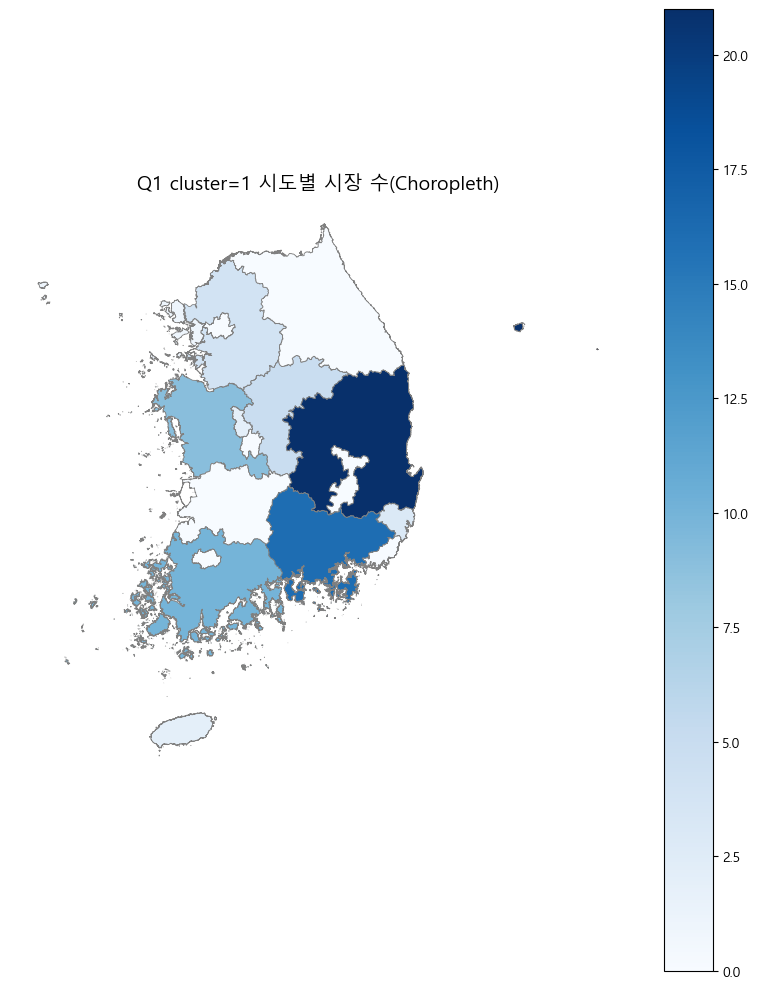

max: 21.0
    CTPRVN_CD  market_cnt
13         47        21.0
14         48        16.0
12         46        10.0
10         44         9.0
9          43         5.0
8          41         4.0
6          31         3.0
15         50         2.0
7          36         2.0
3          28         1.0


In [ ]:
g_map_c1 = g_ct.merge(
    q1_c1_sido[["CTPRVN_CD","market_cnt"]],
    on="CTPRVN_CD",
    how="left"
)
g_map_c1["market_cnt"] = g_map_c1["market_cnt"].fillna(0)

vmax = int(g_map_c1["market_cnt"].max())
vmax = max(vmax, 1)

fig, ax = plt.subplots(figsize=(8, 10))
g_map_c1.plot(
    column="market_cnt",
    cmap="Blues",
    linewidth=0.6,
    edgecolor="grey",
    legend=True,
    ax=ax,
    vmin=0,
    vmax=vmax
)
ax.set_title("Q1 cluster=1 시도별 시장 수(Choropleth)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

print("max:", g_map_c1["market_cnt"].max())
print(g_map_c1[["CTPRVN_CD","market_cnt"]].sort_values("market_cnt", ascending=False).head(10))

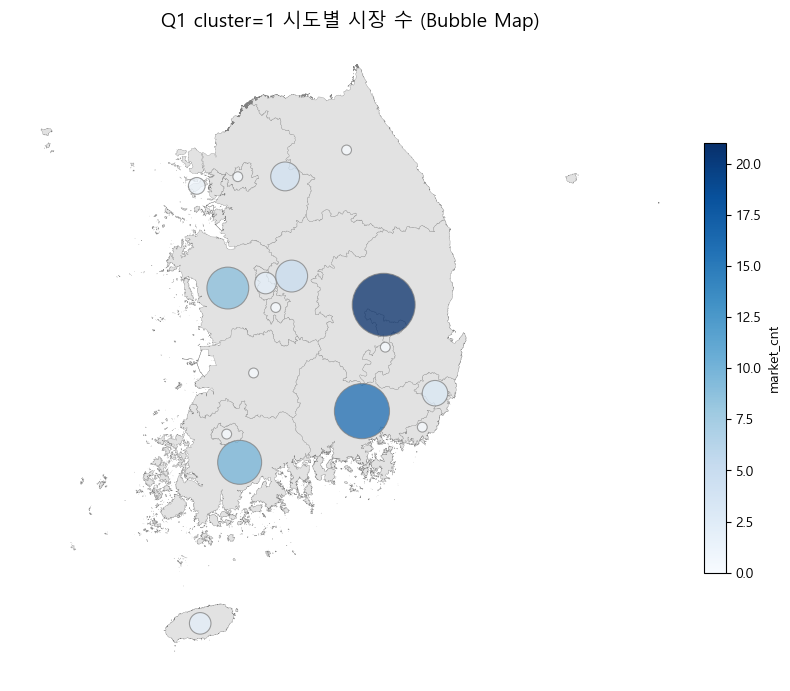

In [151]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 0) 집계: Q1 cluster=1
q1_c1 = q1[q1["cluster"].eq(1)].copy()

q1_c1_sido = (
    q1_c1.groupby(["시도"], as_index=False)
         .size()
         .rename(columns={"size":"market_cnt"})
)

# 1) 시도 한글 -> CTPRVN_CD 매핑(앞에서 쓰던 dict 그대로)
SIDO_TO_CTPRVN = {
    "서울특별시": 11, "부산광역시": 26, "대구광역시": 27, "인천광역시": 28, "광주광역시": 29,
    "대전광역시": 30, "울산광역시": 31, "세종특별자치시": 36, "경기도": 41, "강원도": 51,
    "충청북도": 43, "충청남도": 44, "전라북도": 45, "전라남도": 46,
    "경상북도": 47, "경상남도": 48, "제주특별자치도": 50,
}
def norm_sido(x):
    x = str(x).strip().replace(" ", "")
    alias = {"강원특별자치도":"강원도", "제주도":"제주특별자치도", "세종시":"세종특별자치시"}
    return alias.get(x, x)

q1_c1_sido["시도_norm"] = q1_c1_sido["시도"].map(norm_sido)
q1_c1_sido["CTPRVN_CD"] = q1_c1_sido["시도_norm"].map(SIDO_TO_CTPRVN)

# 2) shp 로드 + count 조인
g_ct = gpd.read_file(r"D:\PP\BC\data\og\ctprvn.shp")
g_ct['CTPRVN_CD'] = g_ct['CTPRVN_CD'].astype(int)
g_map = g_ct.merge(q1_c1_sido[["CTPRVN_CD","market_cnt"]], on="CTPRVN_CD", how="left")
g_map["market_cnt"] = g_map["market_cnt"].fillna(0).astype(int)

# 3) 버블 위치 = (멀티)폴리곤 대표점(centroid보다 지도 밖으로 안 나감)
#g_map = g_map.to_crs(120)  # 도형 좌표계(면적/거리용). 이미 5179면 생략 가능
g_map["pt"] = g_map.geometry.representative_point()
g_map["x"] = g_map["pt"].x
g_map["y"] = g_map["pt"].y

# 4) 원 크기 스케일링 (너무 과/소 방지)
max_cnt = max(g_map["market_cnt"].max(), 1)
g_map["size"] = (g_map["market_cnt"] / max_cnt) * 2000 + 50  # 50~2050 정도

# 5) 그리기
fig, ax = plt.subplots(figsize=(8, 10))
g_map.plot(ax=ax, color="#E2E2E2", edgecolor="grey", linewidth=0.2)

# 원(버블)
ax.scatter(
    g_map["x"], g_map["y"],
    s=g_map["size"],
    c=g_map["market_cnt"],
    cmap="Blues",
    alpha=0.75,
    edgecolors="grey",
    linewidths=0.8
)


topN = 0
top = g_map.sort_values("market_cnt", ascending=False).head(topN)
for _, r in top.iterrows():
    ax.text(r["x"], r["y"], f"{r['market_cnt']}", ha="center", va="center", fontsize=10)

ax.set_title("Q1 cluster=1 시도별 시장 수 (Bubble Map)", fontsize=14)
ax.axis("off")

# 컬러바
sm = plt.cm.ScalarMappable(cmap="Blues")
sm.set_array(g_map["market_cnt"])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("market_cnt")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

SIG_SHP_PATH = r"D:\PP\BC\data\og\sig.shp"
g_sig = gpd.read_file(SIG_SHP_PATH)


def pick_sig_code_col(cols):
    # 흔한 후보들
    candidates = ["SIG_CD","SIGUNGU_CD","SGG_CD","ADM_CD","CODE","SIG_CD_5"]
    for c in candidates:
        if c in cols:
            return c

    # 휴리스틱: SIG/SGG 들어가고 CD/CODE 들어가는 것
    for c in cols:
        u = c.upper()
        if (("SIG" in u) or ("SGG" in u)) and (("CD" in u) or ("CODE" in u)):
            return c

    raise ValueError("시군구 코드 컬럼을 찾지 못했어. sig.shp columns 출력 보고 코드 컬럼명을 직접 지정해줘.")

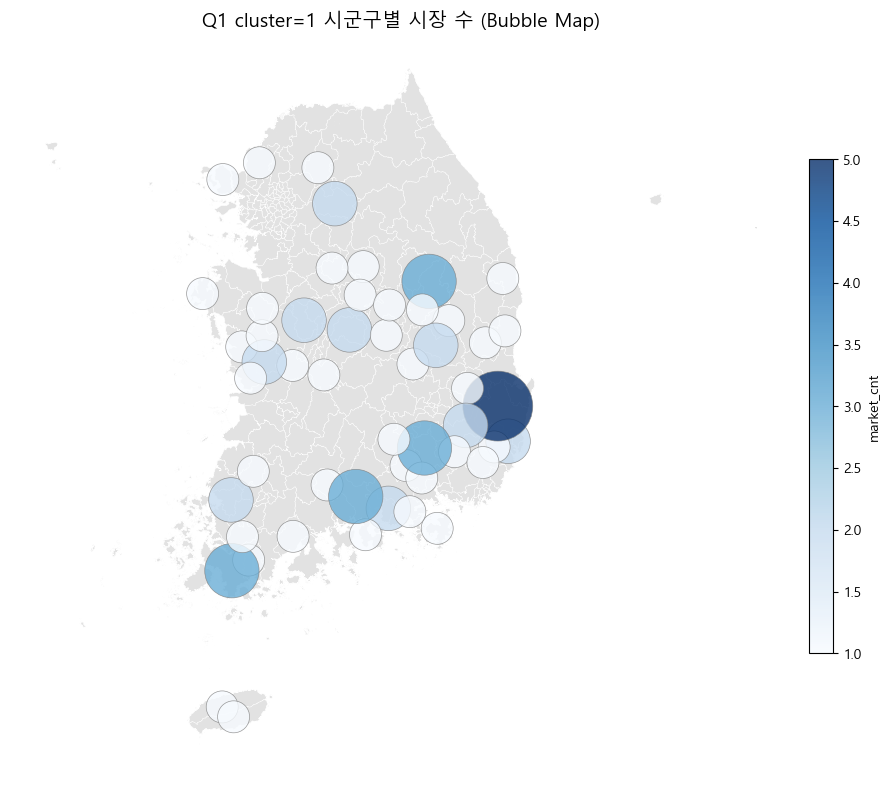

In [188]:
q1_c1 = q1[q1["cluster"].eq(1)].copy()

# 행정기관코드 -> sigungu_cd5 (앞 5자리)
q1_c1["행정기관코드"] = q1_c1["행정기관코드"].astype(str).str.strip()
q1_c1["sigungu_cd5"] = q1_c1["행정기관코드"].str[:5]

# 집계
q1_c1_sig = (
    q1_c1.groupby("sigungu_cd5", as_index=False)
         .size()
         .rename(columns={"size":"market_cnt"})
)
q1_c1_sig["sigungu_cd5"] = q1_c1_sig["sigungu_cd5"].astype(int)

sig_code_col = pick_sig_code_col(list(g_sig.columns))
g_sig[sig_code_col] = g_sig[sig_code_col].astype(str).str.strip()
g_sig["sigungu_cd5"] = g_sig[sig_code_col].str[:5].astype(int)

g_map = g_sig.merge(q1_c1_sig, on="sigungu_cd5", how="left")
g_map["market_cnt"] = g_map["market_cnt"].fillna(0).astype(int)

# 대표점(폴리곤 밖으로 안 나감)
g_map["pt"] = g_map.geometry.representative_point()
g_map["x"] = g_map["pt"].x
g_map["y"] = g_map["pt"].y

max_cnt = max(g_map["market_cnt"].max(), 1)
g_map["size"] = (g_map["market_cnt"] / max_cnt) * 2500 + 30
g_plot = g_map[g_map["market_cnt"] > 0].copy()


fig, ax = plt.subplots(figsize=(9, 10))
g_map.plot(ax=ax, color="#E2E2E2", edgecolor="white", linewidth=0.3)

sc = ax.scatter(
    g_plot["x"], g_plot["y"],
    s=g_plot["size"],
    c=g_plot["market_cnt"],
    cmap="Blues",
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.5
)

ax.set_title("Q1 cluster=1 시군구별 시장 수 (Bubble Map)", fontsize=14)
ax.axis("off")

cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("market_cnt")

plt.tight_layout()
plt.show()


### 0번 군집

In [ ]:
# 예: Q1, cluster=0만
q1_c0 = q1[q1["cluster"].eq(0)].copy()

q1_c0_sido = agg_region_counts(q1_c0, region_cols=("시도",), group_cols=("quadrant","cluster"))
q1_c0_sigungu = agg_region_counts(q1_c0, region_cols=("시도","시군구"), group_cols=("quadrant","cluster"))

print("Q1 cluster=0 시도 TOP")
print(q1_c0_sido.head(20))

print("Q1 cluster=0 시군구 TOP")
print(q1_c0_sigungu.head(30))


Q1 cluster=0 시도 TOP
         시도      quadrant  cluster  market_cnt
6     부산광역시  Q1_우상(최우선위험)        0          33
1      경상남도  Q1_우상(최우선위험)        0          30
4     대구광역시  Q1_우상(최우선위험)        0          22
0       경기도  Q1_우상(최우선위험)        0          17
7     서울특별시  Q1_우상(최우선위험)        0          16
2      경상북도  Q1_우상(최우선위험)        0          12
9     인천광역시  Q1_우상(최우선위험)        0           9
3     광주광역시  Q1_우상(최우선위험)        0           6
10     전라남도  Q1_우상(최우선위험)        0           5
8     울산광역시  Q1_우상(최우선위험)        0           4
5     대전광역시  Q1_우상(최우선위험)        0           3
11  제주특별자치도  Q1_우상(최우선위험)        0           3
12     충청남도  Q1_우상(최우선위험)        0           2
13     충청북도  Q1_우상(최우선위험)        0           2
Q1 cluster=0 시군구 TOP
         시도   시군구      quadrant  cluster  market_cnt
14     경상남도   창원시  Q1_우상(최우선위험)        0          21
26    대구광역시    남구  Q1_우상(최우선위험)        0           6
41    부산광역시   사하구  Q1_우상(최우선위험)        0           6
29    대구광역시    북구  Q1_우상(최우선위험)        0  

In [108]:
oof[(oof['시도'] == '경상남도') & (oof['시군구'] == '창원시')].sort_values(by='빈점포율', ascending=False)[['시장명', '빈점포율','pred', 'residual', 'risk_index', 'quadrant']].head(10)

,시장명,빈점포율,pred,residual,risk_index,quadrant
324,마천시장,0.750000,0.098615,0.651385,4.138965,Q1_우상(최우선위험)
336,석전시장,0.705882,0.356151,0.349731,2.993135,Q1_우상(최우선위험)
331,북마산중앙시장,0.695238,0.345925,0.349313,2.959302,Q1_우상(최우선위험)
345,중앙시장(창원중앙시장),0.693333,0.405677,0.287657,2.746771,Q1_우상(최우선위험)
335,서마산시장,0.675676,0.093238,0.582438,3.681348,Q1_우상(최우선위험)
342,양덕중앙시장,0.603604,0.548072,0.055532,1.695099,Q1_우상(최우선위험)
340,신마산반월시장,0.487500,0.067185,0.420315,2.564452,Q1_우상(최우선위험)
325,명곡종합상가,0.475728,0.302076,0.173652,1.701548,Q1_우상(최우선위험)
313,기산프라자,0.367089,0.188093,0.178995,1.388474,Q1_우상(최우선위험)
352,합성대로상가,0.272727,0.206529,0.066198,0.722784,Q1_우상(최우선위험)


### 시각화

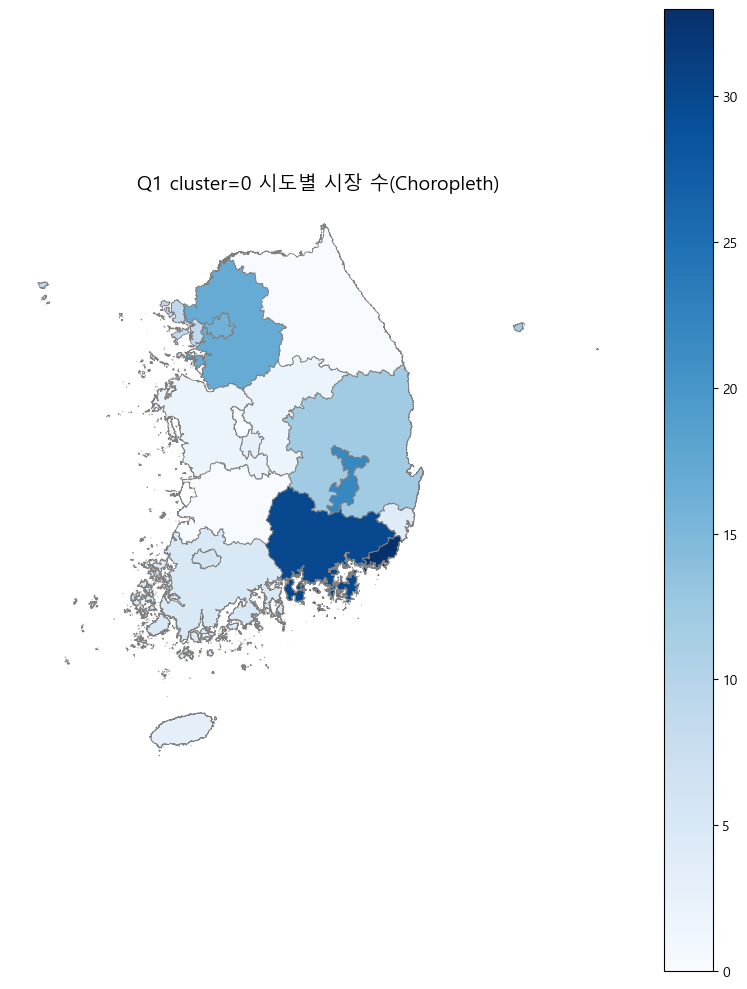

max: 33.0
    CTPRVN_CD  market_cnt
1          26        33.0
14         48        30.0
2          27        22.0
8          41        17.0
0          11        16.0
13         47        12.0
3          28         9.0
4          29         6.0
12         46         5.0
6          31         4.0


In [136]:
q1_c0_sido["시도_norm"] = q1_c0_sido["시도"].map(norm_sido)
q1_c0_sido["CTPRVN_CD"] = q1_c0_sido["시도_norm"].map(SIDO_TO_CTPRVN)
g_map_c0 = g_ct.merge(
    q1_c0_sido[["CTPRVN_CD","market_cnt"]],
    on="CTPRVN_CD",
    how="left"
)
g_map_c0["market_cnt"] = g_map_c0["market_cnt"].fillna(0)

vmax = int(g_map_c0["market_cnt"].max())
vmax = max(vmax, 1)

fig, ax = plt.subplots(figsize=(8, 10))
g_map_c0.plot(
    column="market_cnt",
    cmap="Blues",
    linewidth=0.6,
    edgecolor="grey",
    legend=True,
    ax=ax,
    vmin=0,
    vmax=vmax
)
ax.set_title("Q1 cluster=0 시도별 시장 수(Choropleth)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

print("max:", g_map_c0["market_cnt"].max())
print(g_map_c0[["CTPRVN_CD","market_cnt"]].sort_values("market_cnt", ascending=False).head(10))

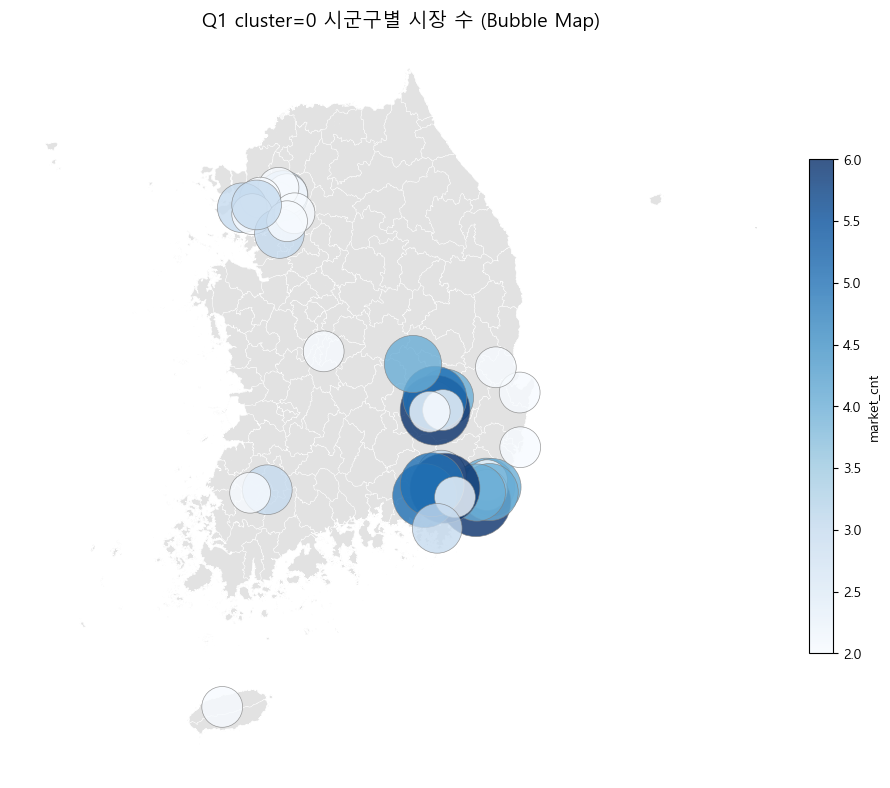

In [196]:
q1_c0 = q1[q1["cluster"].eq(0)].copy()

# 행정기관코드 -> sigungu_cd5 (앞 5자리)
q1_c0["행정기관코드"] = q1_c0["행정기관코드"].astype(str).str.strip()
q1_c0["sigungu_cd5"] = q1_c0["행정기관코드"].str[:5]

# 집계
q1_c0_sig = (
    q1_c0.groupby("sigungu_cd5", as_index=False)
         .size()
         .rename(columns={"size":"market_cnt"})
)
q1_c0_sig["sigungu_cd5"] = q1_c0_sig["sigungu_cd5"].astype(int)

sig_code_col = pick_sig_code_col(list(g_sig.columns))
g_sig[sig_code_col] = g_sig[sig_code_col].astype(str).str.strip()
g_sig["sigungu_cd5"] = g_sig[sig_code_col].str[:5].astype(int)

g_map = g_sig.merge(q1_c0_sig, on="sigungu_cd5", how="left")
g_map["market_cnt"] = g_map["market_cnt"].fillna(0).astype(int)

# 대표점(폴리곤 밖으로 안 나감)
g_map["pt"] = g_map.geometry.representative_point()
g_map["x"] = g_map["pt"].x
g_map["y"] = g_map["pt"].y

max_cnt = max(g_map["market_cnt"].max(), 1)
g_map["size"] = (g_map["market_cnt"] / max_cnt) * 2500 + 30
g_plot = g_map[g_map["market_cnt"] > 1].copy()


fig, ax = plt.subplots(figsize=(9, 10))
g_map.plot(ax=ax, color="#E2E2E2", edgecolor="white", linewidth=0.3)

sc = ax.scatter(
    g_plot["x"], g_plot["y"],
    s=g_plot["size"],
    c=g_plot["market_cnt"],
    cmap="Blues",
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.5
)

ax.set_title("Q1 cluster=0 시군구별 시장 수 (Bubble Map)", fontsize=14)
ax.axis("off")

cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("market_cnt")

plt.tight_layout()
plt.show()


### 2번 군집

In [109]:
# 예: Q1, cluster=0만
q1_c2 = q1[q1["cluster"].eq(2)].copy()

q1_c2_sido = agg_region_counts(q1_c2, region_cols=("시도",), group_cols=("quadrant","cluster"))
q1_c2_sigungu = agg_region_counts(q1_c2, region_cols=("시도","시군구"), group_cols=("quadrant","cluster"))

print("Q1 cluster=2 시도 TOP")
print(q1_c2_sido.head(20))

print("Q1 cluster=2 시군구 TOP")
print(q1_c2_sigungu.head(30))


Q1 cluster=2 시도 TOP
      시도      quadrant  cluster  market_cnt
5  서울특별시  Q1_우상(최우선위험)        2          15
4  부산광역시  Q1_우상(최우선위험)        2           9
2  대구광역시  Q1_우상(최우선위험)        2           2
6   충청북도  Q1_우상(최우선위험)        2           2
0    경기도  Q1_우상(최우선위험)        2           1
1  광주광역시  Q1_우상(최우선위험)        2           1
3  대전광역시  Q1_우상(최우선위험)        2           1
Q1 cluster=2 시군구 TOP
       시도   시군구      quadrant  cluster  market_cnt
13  서울특별시    중구  Q1_우상(최우선위험)        2           9
7   부산광역시    중구  Q1_우상(최우선위험)        2           5
6   부산광역시   사상구  Q1_우상(최우선위험)        2           2
5   부산광역시  부산진구  Q1_우상(최우선위험)        2           2
11  서울특별시   용산구  Q1_우상(최우선위험)        2           2
2   대구광역시    북구  Q1_우상(최우선위험)        2           1
3   대구광역시    중구  Q1_우상(최우선위험)        2           1
0     경기도   수원시  Q1_우상(최우선위험)        2           1
4   대전광역시    동구  Q1_우상(최우선위험)        2           1
1   광주광역시    동구  Q1_우상(최우선위험)        2           1
9   서울특별시   서초구  Q1_우상(최우선위험)        2        

In [111]:
oof[(oof['시도'] == '부산광역시') & (oof['시군구'] == '중구')].sort_values(by='빈점포율', ascending=False)[['시장명', '빈점포율','pred', 'residual', 'risk_index', 'quadrant']].head(10)

,시장명,빈점포율,pred,residual,risk_index,quadrant
271,아리랑거리,0.807692,0.356759,0.450933,3.642638,Q1_우상(최우선위험)
273,월드밸리,0.371711,0.285180,0.086531,1.092529,Q1_우상(최우선위험)
266,보수종합시장,0.250000,0.113964,0.136036,0.887701,Q1_우상(최우선위험)
274,자갈치시장,0.187500,0.078672,0.108828,0.606058,Q1_우상(최우선위험)
269,새영주시장,0.166667,0.060229,0.106437,0.534570,Q1_우상(최우선위험)
267,부산데파트,0.111111,0.136721,-0.025609,-0.077432,Q4_우하(잠재/개입효과)
270,신창상가,0.103093,0.132071,-0.028979,-0.113158,Q4_우하(잠재/개입효과)
275,창선상가,0.075758,0.103571,-0.027813,-0.192533,Q4_우하(잠재/개입효과)
272,영주시장,0.058140,0.266001,-0.207861,-0.849893,Q4_우하(잠재/개입효과)
265,만물의거리시장,0.013699,0.166469,-0.152771,-0.800578,Q3_좌하(안정)


### 시각화

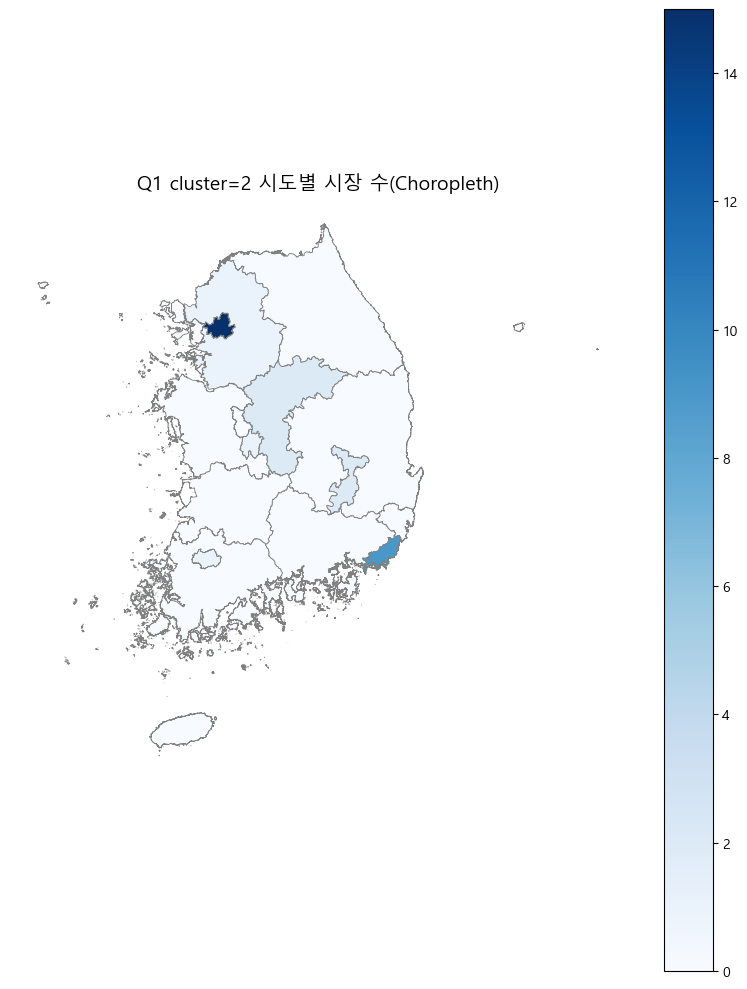

max: 15.0
   CTPRVN_CD  market_cnt
0         11        15.0
1         26         9.0
2         27         2.0
9         43         2.0
4         29         1.0
8         41         1.0
5         30         1.0
6         31         0.0
3         28         0.0
7         36         0.0


In [135]:
q1_c2_sido["시도_norm"] = q1_c2_sido["시도"].map(norm_sido)
q1_c2_sido["CTPRVN_CD"] = q1_c2_sido["시도_norm"].map(SIDO_TO_CTPRVN)
g_map_c2 = g_ct.merge(
    q1_c2_sido[["CTPRVN_CD","market_cnt"]],
    on="CTPRVN_CD",
    how="left"
)
g_map_c2["market_cnt"] = g_map_c2["market_cnt"].fillna(0)

vmax = int(g_map_c2["market_cnt"].max())
vmax = max(vmax, 1)

fig, ax = plt.subplots(figsize=(8, 10))
g_map_c2.plot(
    column="market_cnt",
    cmap="Blues",
    linewidth=0.6,
    edgecolor="grey",
    legend=True,
    ax=ax,
    vmin=0,
    vmax=vmax
)
ax.set_title("Q1 cluster=2 시도별 시장 수(Choropleth)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

print("max:", g_map_c2["market_cnt"].max())
print(g_map_c2[["CTPRVN_CD","market_cnt"]].sort_values("market_cnt", ascending=False).head(10))

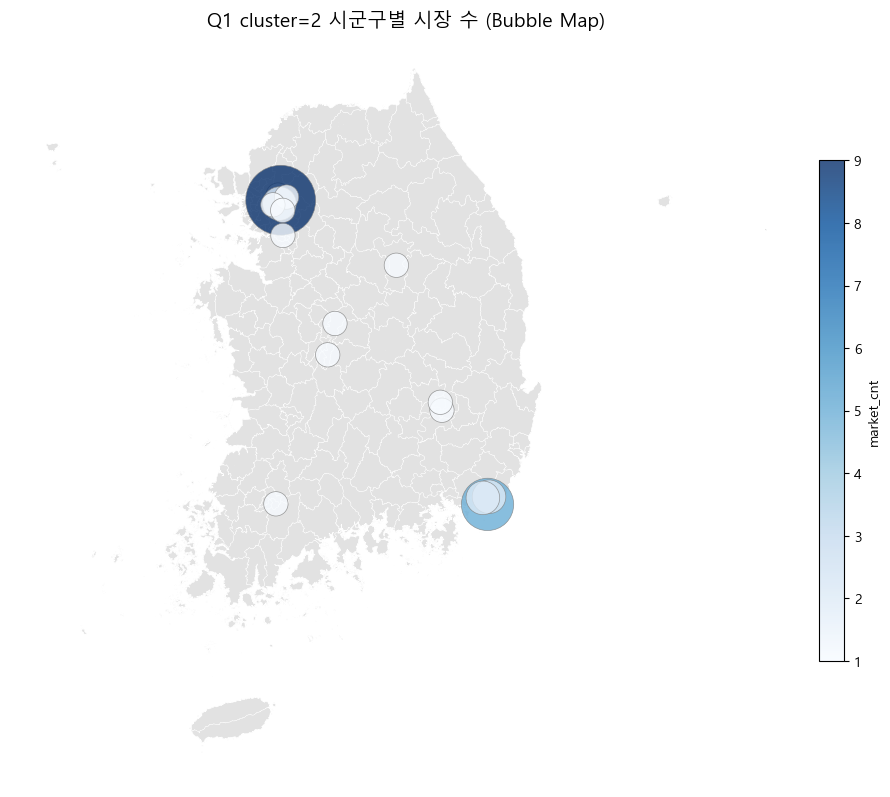

In [198]:
q1_c2 = q1[q1["cluster"].eq(2)].copy()

# 행정기관코드 -> sigungu_cd5 (앞 5자리)
q1_c2["행정기관코드"] = q1_c2["행정기관코드"].astype(str).str.strip()
q1_c2["sigungu_cd5"] = q1_c2["행정기관코드"].str[:5]

# 집계
q1_c2_sig = (
    q1_c2.groupby("sigungu_cd5", as_index=False)
         .size()
         .rename(columns={"size":"market_cnt"})
)
q1_c2_sig["sigungu_cd5"] = q1_c2_sig["sigungu_cd5"].astype(int)

sig_code_col = pick_sig_code_col(list(g_sig.columns))
g_sig[sig_code_col] = g_sig[sig_code_col].astype(str).str.strip()
g_sig["sigungu_cd5"] = g_sig[sig_code_col].str[:5].astype(int)

g_map = g_sig.merge(q1_c2_sig, on="sigungu_cd5", how="left")
g_map["market_cnt"] = g_map["market_cnt"].fillna(0).astype(int)

# 대표점(폴리곤 밖으로 안 나감)
g_map["pt"] = g_map.geometry.representative_point()
g_map["x"] = g_map["pt"].x
g_map["y"] = g_map["pt"].y

max_cnt = max(g_map["market_cnt"].max(), 1)
g_map["size"] = (g_map["market_cnt"] / max_cnt) * 2500 + 30
g_plot = g_map[g_map["market_cnt"] > 0].copy()


fig, ax = plt.subplots(figsize=(9, 10))
g_map.plot(ax=ax, color="#E2E2E2", edgecolor="white", linewidth=0.3)

sc = ax.scatter(
    g_plot["x"], g_plot["y"],
    s=g_plot["size"],
    c=g_plot["market_cnt"],
    cmap="Blues",
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.5
)

ax.set_title("Q1 cluster=2 시군구별 시장 수 (Bubble Map)", fontsize=14)
ax.axis("off")

cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("market_cnt")

plt.tight_layout()
plt.show()
